# Research Paper Answer Bot — GenAI Pinnacle Plus Capstone

**A Retrieval-Augmented Generation system over 15 seminal GenAI/LLM research papers.**

Every answer is grounded in the corpus and cites its **top-3 supporting passages with paper title and page number**.

| | |
|---|---|
| **Corpus** | 15 arXiv papers (Attention, BERT, GPT-3, RAG, DPR, InstructGPT, LoRA, Chinchilla, Llama 2, CoT, ReAct, Mixtral, FlashAttention, Self-RAG, CRAG) |
| **Chunking** | fixed (token windows) · recursive (structure-aware) · semantic (embedding-driven) |
| **Embeddings** | `all-MiniLM-L6-v2` · `BAAI/bge-small-en-v1.5` · `nomic-embed-text-v1.5` (served locally) |
| **Vector DB** | ChromaDB (persistent, cosine) |
| **Retrieval** | dense · MMR · BM25 · hybrid (RRF) · cross-encoder rerank · multi-query |
| **LLM** | local OpenAI-compatible server (LM Studio) — no paid API anywhere in this project |
| **Stretch goals** | ✅ conversational memory · ✅ Streamlit app · ✅ Corrective RAG with web fallback |

The notebook is organised to match the capstone brief: **Step 1 → Step 8**, then evaluation and conclusions.
All logic lives in the installed package `src/rag_bot/` — the notebook is the narrative and the evidence,
not a dumping ground for implementation. That separation is deliberate: the same code runs in the notebook,
the CLI scripts and the Streamlit app, so what is measured here is exactly what ships.

## 0. Setup

Imports, configuration and a preflight check against the local LLM server.

In [1]:
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from rag_bot.config import settings
from rag_bot.logging_utils import set_seed, setup_logging

setup_logging("WARNING")   # keep the notebook output readable
set_seed(42)               # reproducibility
settings.ensure_dirs()
pd.set_option("display.max_colwidth", 90)

EVAL_K = 3    # metrics are computed at the same k the bot cites with

print(f"LLM server : {settings.lmstudio_base_url}")
print(f"LLM model  : {settings.llm_model}")
print(f"Chroma dir : {settings.chroma_dir}")

LLM server : http://10.42.80.38:1234/v1
LLM model  : liquid/lfm2.5-1.2b
Chroma dir : /home/suryaguru/StudioProjects/capstone/research-paper-bot/chroma


In [2]:
from rag_bot.generation.llm import health_check, list_models

print("Models advertised by the server:")
for m in list_models():
    print("  -", m)

ok, detail = health_check()
print(f"\nChat model loads: {ok} -> {detail}")

Models advertised by the server:
  - liquid/lfm2.5-1.2b
  - text-embedding-nomic-embed-text-v1.5
  - mistralai/ministral-3-3b
  - qwen/qwen3-4b-2507
  - qwen/qwen3-vl-4b
  - qwen/qwen3-4b

Chat model loads: True -> ready


> **Note on model availability.** The server advertises several chat models, but LM Studio only
> reports a load failure at first completion — larger models fail to load on the host GPU. The
> pipeline therefore treats the model as configuration (`LLM_MODEL`), and every LLM-dependent step
> degrades gracefully rather than crashing. This is why `liquid/lfm2.5-1.2b` is the default here;
> pointing `.env` at a larger model changes nothing else in the code.

---
## Step 1 — Data Collection & Document Loading

15 seminal papers are downloaded from arXiv (open access). Each PDF is parsed **page by page** with
`pypdf`, and every page keeps the metadata that citations depend on: `title`, `arxiv_id`, `page`,
`source`. Titles come from a curated `arxiv_id → title` map rather than from page-1 text extraction,
which reorders columns and mangles ligatures — a wrong title in a citation is worse than no citation.

Cleaning handles the classic PDF artefacts: ligatures (`ﬁ` → `fi`), words hyphenated across line
breaks, control characters, and runaway blank lines.

In [3]:
from rag_bot.ingest.download import download_corpus
from rag_bot.ingest.corpus import PAPERS

pdf_paths = download_corpus()          # cached: skips files already present
print(f"{len(pdf_paths)} PDFs in {settings.raw_dir}")

pd.DataFrame([{"arXiv": p.arxiv_id, "year": p.year, "topic": p.topic, "title": p.title} for p in PAPERS])

15 PDFs in /home/suryaguru/StudioProjects/capstone/research-paper-bot/data/raw


,arXiv,year,topic,title
0,1706.03762,2017,architecture,Attention Is All You Need
1,1810.04805,2018,pretraining,BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding
2,2005.14165,2020,scaling,Language Models are Few-Shot Learners
3,2005.11401,2020,rag,Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks
4,2004.04906,2020,rag,Dense Passage Retrieval for Open-Domain Question Answering
5,2203.02155,2022,alignment,Training language models to follow instructions with human feedback
6,2106.09685,2021,peft,LoRA: Low-Rank Adaptation of Large Language Models
7,2203.15556,2022,scaling,Training Compute-Optimal Large Language Models
8,2307.09288,2023,models,Llama 2: Open Foundation and Fine-Tuned Chat Models
9,2201.11903,2022,prompting,Chain-of-Thought Prompting Elicits Reasoning in Large Language Models


In [4]:
from rag_bot.ingest.loader import load_corpus

pages, load_report = load_corpus()

print(f"files loaded     : {load_report.files}")
print(f"pages kept       : {load_report.pages_kept}")
print(f"pages skipped    : {load_report.pages_skipped}  ({load_report.skip_rate:.1%})")
print(f"failures         : {load_report.failures or 'none'}")
print()
print("Example of a skipped page (too little extractable text — cover art or a full-page figure):")
print(load_report.skipped_detail[:3])

files loaded     : 15
pages kept       : 512
pages skipped    : 2  (0.4%)
failures         : none

Example of a skipped page (too little extractable text — cover art or a full-page figure):
[('Language Models are Few-Shot Learners', 65, 112), ('Language Models are Few-Shot Learners', 67, 103)]


### EDA 1 — corpus composition

In [5]:
page_df = pd.DataFrame([
    {"title": d.metadata["title"], "page": d.metadata["page"], "chars": len(d.page_content)}
    for d in pages
])

by_paper = (page_df.groupby("title")
            .agg(pages=("page", "count"), total_chars=("chars", "sum"), mean_chars=("chars", "mean"))
            .sort_values("pages", ascending=False)
            .round(0).astype(int))
by_paper

,pages,total_chars,mean_chars
title,,,
Llama 2: Open Foundation and Fine-Tuned Chat Models,77,260303,3381
Language Models are Few-Shot Learners,73,236899,3245
Training language models to follow instructions with human feedback,68,182031,2677
Chain-of-Thought Prompting Elicits Reasoning in Large Language Models,43,135863,3160
Training Compute-Optimal Large Language Models,36,95750,2660
FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness,34,108366,3187
ReAct: Synergizing Reasoning and Acting in Language Models,33,109229,3310
"Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection",30,105726,3524
LoRA: Low-Rank Adaptation of Large Language Models,26,82512,3174


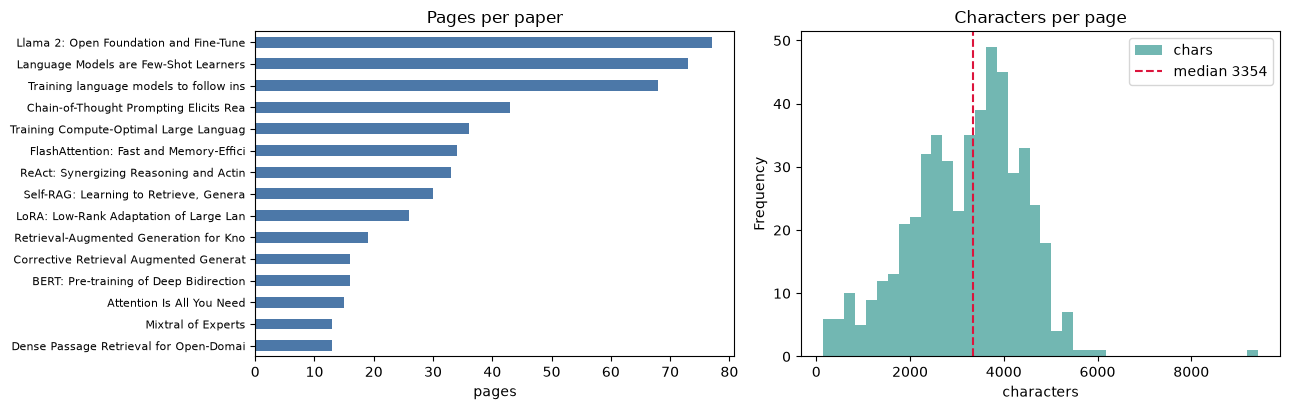

total pages 512 | median 3354 chars | p95 4849 chars


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

by_paper["pages"].sort_values().plot(kind="barh", ax=axes[0], color="#4c78a8")
axes[0].set_title("Pages per paper")
axes[0].set_xlabel("pages"); axes[0].set_ylabel("")
axes[0].set_yticklabels([t.get_text()[:38] for t in axes[0].get_yticklabels()], fontsize=8)

page_df["chars"].plot(kind="hist", bins=40, ax=axes[1], color="#72b7b2")
axes[1].set_title("Characters per page")
axes[1].set_xlabel("characters")
axes[1].axvline(page_df["chars"].median(), color="crimson", ls="--",
                label=f'median {page_df["chars"].median():.0f}')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"total pages {len(page_df)} | median {page_df['chars'].median():.0f} chars "
      f"| p95 {page_df['chars'].quantile(0.95):.0f} chars")

**Observation.** Page length varies by an order of magnitude — dense two-column body pages run to
several thousand characters while reference and appendix pages are far shorter. That spread is the
reason chunking strategy is worth measuring rather than assuming: a fixed window that suits a dense
body page wastes an index slot on a sparse one, and a structure-aware splitter behaves differently on
each. The comparison is settled with numbers in Step 5, not here.

---
## Step 2 — Text Chunking Strategy

Three strategies are compared:

| Strategy | How it splits | Trade-off |
|---|---|---|
| `fixed` | 512-token windows, 64 overlap | predictable size; cuts mid-sentence |
| `recursive` | paragraph → sentence → word boundaries, 1000 chars / 150 overlap | respects structure; variable size |
| `semantic` | splits where consecutive sentence embeddings diverge | topically coherent; slowest, needs an embedding model |

Overlap matters: too little and a definition split across a boundary is unretrievable; too much and
the index inflates with near-duplicates that crowd out diverse results.

In [7]:
from rag_bot.ingest.chunking import chunk_documents, chunk_stats

chunk_sets, rows = {}, []
for strategy in ["fixed", "recursive", "semantic"]:
    t0 = time.perf_counter()
    chunks = chunk_documents(pages, strategy)
    elapsed = time.perf_counter() - t0
    chunk_sets[strategy] = chunks
    s = chunk_stats(chunks, strategy)
    rows.append({"strategy": s.strategy, "chunks": s.n_chunks, "mean_chars": round(s.mean_chars),
                 "p95_chars": round(s.p95_chars), "min": s.min_chars, "max": s.max_chars,
                 "seconds": round(elapsed, 1)})

chunk_table = pd.DataFrame(rows)
chunk_table

17:09:52 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,strategy,chunks,mean_chars,p95_chars,min,max,seconds
0,fixed,1212,1485,2296,131,2673,0.4
1,recursive,2100,860,995,68,1000,0.0
2,semantic,2067,790,2372,30,9428,70.2


In [8]:
# The citation contract: no chunk may lose its title or page.
for strategy, chunks in chunk_sets.items():
    assert all(c.metadata.get("title") and isinstance(c.metadata.get("page"), int) for c in chunks)
    assert len({c.metadata["chunk_id"] for c in chunks}) == len(chunks)  # ids unique
print("metadata preserved and chunk ids unique for all three strategies ✓")

example = chunk_sets["recursive"][40]
print(f"\nExample chunk -> {example.metadata['title']} (page {example.metadata['page']})")
print(example.page_content[:400], "...")

metadata preserved and chunk ids unique for all three strategies ✓

Example chunk -> Attention Is All You Need (page 11)
the limits of language modeling. arXiv preprint arXiv:1602.02410, 2016.
[16] Łukasz Kaiser and Samy Bengio. Can active memory replace attention? In Advances in Neural
Information Processing Systems, (NIPS), 2016.
[17] Łukasz Kaiser and Ilya Sutskever. Neural GPUs learn algorithms. In International Conference
on Learning Representations (ICLR), 2016.
[18] Nal Kalchbrenner, Lasse Espeholt, Karen Sim ...


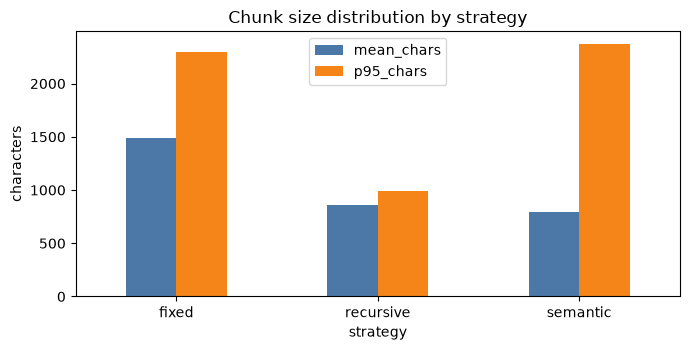

In [9]:
ax = chunk_table.set_index("strategy")[["mean_chars", "p95_chars"]].plot(
    kind="bar", figsize=(7, 3.6), rot=0, color=["#4c78a8", "#f58518"])
ax.set_title("Chunk size distribution by strategy"); ax.set_ylabel("characters")
plt.tight_layout(); plt.show()

**Observation.** The three strategies differ in chunk count, chunk length and — most sharply — in
preprocessing cost: semantic chunking must embed every sentence before it can split, so it is far
slower than the other two. Whether that cost buys retrieval quality is answered in Step 5a.

---
## Step 3 — Embedding Models

Three models are compared, **all free**: two run locally on the GPU, one is served by the same
LM Studio instance as the LLM. The commercial OpenAI embeddings suggested by the brief are
deliberately replaced by a locally-served API model — same architectural role (HTTP embedding
service, different vendor), zero cost.

| key | model | dim | served by |
|---|---|---|---|
| `minilm` | `sentence-transformers/all-MiniLM-L6-v2` | 384 | local GPU |
| `bge-small` | `BAAI/bge-small-en-v1.5` | 384 | local GPU |
| `nomic` | `text-embedding-nomic-embed-text-v1.5` | 768 | LM Studio HTTP |

BGE and Nomic are *asymmetric*: they expect an instruction prefix on the query side only. The
registry applies those prefixes automatically — getting this wrong silently costs several points of recall.

In [10]:
from rag_bot.embeddings.registry import EMBEDDING_MODELS, get_embeddings

pd.DataFrame([{
    "key": s.key, "model": s.model_name, "dim": s.dim, "provider": s.provider,
    "query_prefix": s.query_prefix or "—", "notes": s.notes,
} for s in EMBEDDING_MODELS.values()])

,key,model,dim,provider,query_prefix,notes
0,minilm,sentence-transformers/all-MiniLM-L6-v2,384,huggingface,—,"Fast general-purpose baseline, 22M params."
1,bge-small,BAAI/bge-small-en-v1.5,384,huggingface,Represent this sentence for searching relevant passages:,Retrieval-tuned; asymmetric query prefix required by the model card.
2,nomic,text-embedding-nomic-embed-text-v1.5,768,lmstudio,search_query:,"Served by LM Studio; 8k context, task-prefix conditioned."


In [11]:
# Sanity check: do the models agree on what is similar? A quick qualitative probe.
import numpy as np

probe_pairs = [
    ("scaled dot-product attention", "attention weights computed with softmax over QK^T"),
    ("scaled dot-product attention", "low-rank adaptation of pretrained weights"),
]

rows = []
for key in EMBEDDING_MODELS:
    emb = get_embeddings(key)
    for a, b in probe_pairs:
        va, vb = np.array(emb.embed_query(a)), np.array(emb.embed_query(b))
        cos = float(va @ vb / (np.linalg.norm(va) * np.linalg.norm(vb)))
        rows.append({"model": key, "pair": f"{a[:28]}… vs {b[:34]}…", "cosine": round(cos, 3)})

pd.DataFrame(rows).pivot(index="pair", columns="model", values="cosine")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

model,bge-small,minilm,nomic
pair,,,
scaled dot-product attention… vs attention weights computed with so…,0.758,0.358,0.648
scaled dot-product attention… vs low-rank adaptation of pretrained …,0.656,0.211,0.525


**Observation.** All three separate the related pair from the unrelated one, but the *margin*
differs. A wide margin means the model discriminates well at retrieval time; a narrow one means
neighbouring topics will contaminate the top-k. Cosine probes are only indicative — the decision is
made on the gold set below.

---
## Step 4 — Vector Database (ChromaDB)

ChromaDB is used in persistent mode with cosine distance. **One collection per
(embedding model × chunking strategy)** — mixing 384-d and 768-d vectors in one collection is not
merely wasteful, it is invalid, and keeping the pairs separate makes every experiment re-runnable
without a rebuild.

Embeddings are cached on disk by `sha256(model | text)`, so re-running this notebook re-embeds nothing.

In [12]:
from rag_bot.store.chroma_store import build_index, get_store, store_size, collection_name

BEST_CHUNKER = "recursive"   # provisional; re-selected with hard numbers in Step 5a

index_rows = []
for key in ["minilm", "bge-small", "nomic"]:
    _, report = build_index(chunk_sets[BEST_CHUNKER], embed_key=key, chunker=BEST_CHUNKER)
    index_rows.append({"embedding": key, "collection": report.collection, "chunks": report.n_chunks,
                       "dim": report.dim, "build_s": round(report.build_seconds, 1),
                       "cache_hits": report.cache_hits, "cache_misses": report.cache_misses})

pd.DataFrame(index_rows)

,embedding,collection,chunks,dim,build_s,cache_hits,cache_misses
0,minilm,papers__minilm__recursive,2100,384,2.4,2100,0
1,bge-small,papers__bge_small__recursive,2100,384,2.1,2100,0
2,nomic,papers__nomic__recursive,2100,768,2.3,2100,0


In [13]:
# Metadata filtering works end to end — this is what makes per-paper citation and filtering possible.
store = get_store("bge-small", BEST_CHUNKER)
print("chunks in collection:", store_size(store))

hits = store.similarity_search(
    "How is the rank r chosen?", k=3,
    filter={"title": "LoRA: Low-Rank Adaptation of Large Language Models"},
)
for h in hits:
    print(f"  {h.metadata['title'][:44]:44s} p.{h.metadata['page']:>3}  {h.page_content[:70]}…")

chunks in collection: 2100
  LoRA: Low-Rank Adaptation of Large Language  p. 10  captures enough information in ∆W such that it is preferable to adapt …
  LoRA: Low-Rank Adaptation of Large Language  p. 10  Table 6 shows that, surprisingly, LoRA already performs competitively …
  LoRA: Low-Rank Adaptation of Large Language  p. 13  tuning. 3) We mostly depend on heuristics to select the weight matrice…


---
## Step 5 — Retrieval Strategies

Six strategies, evaluated on the gold question set (Step 7 describes it). Retrieval is graded
*before* generation because it is the binding constraint: no prompt can rescue context that never
contained the answer.

| Strategy | Mechanism |
|---|---|
| `dense` | cosine similarity over embeddings |
| `mmr` | Maximal Marginal Relevance — relevance minus redundancy |
| `bm25` | sparse lexical matching |
| `hybrid` | BM25 + dense fused by weighted **Reciprocal Rank Fusion** |
| `rerank` | hybrid candidates (k=20) rescored by a cross-encoder |
| `multiquery` | LLM rewrites the query 3 ways, results fused by RRF |

RRF is used rather than score blending because BM25 scores and cosine similarities are on
incompatible scales — only ranks are comparable.

**Metrics**, computed at **k=3** — the same budget the bot cites with, so the evaluation measures the
context the LLM actually sees:

* `hit@3` — did the correct paper appear at all
* `MRR` — how high it ranked
* `nDCG` — rank-discounted gain
* `page_hit` — did a retrieved chunk land on (or adjacent to) the expected page
* `latency_ms` — cost per query

The full grid is also run at k=5 by `scripts/run_experiments.py`; the reports live in
`reports/experiments_k3.md` and `reports/experiments_k5.md`.

In [14]:
from rag_bot.evaluation.dataset import ANSWERABLE, GOLD_SET, UNANSWERABLE
from rag_bot.evaluation.retrieval_metrics import evaluate_retriever
from rag_bot.retrieval.factory import DESCRIPTIONS, build_retriever

print(f"gold set: {len(GOLD_SET)} questions "
      f"({len(ANSWERABLE)} answerable, {len(UNANSWERABLE)} deliberately out of corpus)")
pd.DataFrame([{"id": q.id, "kind": q.kind, "question": q.question,
               "expected_paper": q.expected_title or "— (must refuse)"} for q in GOLD_SET]).head(20)

gold set: 20 questions (18 answerable, 2 deliberately out of corpus)


,id,kind,question,expected_paper
0,q01,factual,What is scaled dot-product attention and why is it scaled by the square root of d_k?,Attention Is All You Need
1,q02,factual,How many encoder and decoder layers does the base Transformer use?,Attention Is All You Need
2,q03,factual,What are the two pre-training objectives used by BERT?,BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding
3,q04,factual,How many parameters does the largest GPT-3 model have?,Language Models are Few-Shot Learners
4,q05,factual,What is the difference between RAG-Sequence and RAG-Token?,Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks
5,q06,factual,How is the dual-encoder trained in Dense Passage Retrieval and what negatives are used?,Dense Passage Retrieval for Open-Domain Question Answering
6,q07,factual,What are the three steps of the InstructGPT training pipeline?,Training language models to follow instructions with human feedback
7,q08,factual,"In LoRA, which matrices are decomposed and what does the rank r control?",LoRA: Low-Rank Adaptation of Large Language Models
8,q09,factual,What ratio of tokens to parameters does the Chinchilla scaling law recommend?,Training Compute-Optimal Large Language Models
9,q10,factual,What is grouped-query attention and why does Llama 2 use it?,Llama 2: Open Foundation and Fine-Tuned Chat Models


### 5a — Which chunking strategy retrieves best?
Embedding fixed to `bge-small`, retrieval fixed to `dense`, so only the chunker varies.

In [15]:
chunk_eval = []
for strategy in ["fixed", "recursive", "semantic"]:
    build_index(chunk_sets[strategy], embed_key="bge-small", chunker=strategy)
    res = evaluate_retriever(build_retriever("dense", get_store("bge-small", strategy)),
                             k=EVAL_K, label=strategy)
    chunk_eval.append(res.row())

chunk_eval_df = pd.DataFrame(chunk_eval)
BEST_CHUNKER = chunk_eval_df.sort_values("score", ascending=False).iloc[0]["config"]
print("selected chunker:", BEST_CHUNKER)
chunk_eval_df

selected chunker: recursive


,config,k,hit@3,MRR,nDCG,page_hit,score,latency_ms
0,fixed,3,0.944,0.944,0.944,0.722,0.870,9.4
1,recursive,3,1.000,0.935,0.955,0.778,0.889,8.6
2,semantic,3,0.944,0.889,0.894,0.611,0.798,8.1


### 5b — Which embedding model retrieves best?
Chunker fixed to the winner above, retrieval fixed to `dense`.

In [16]:
embed_eval = []
for key in ["minilm", "bge-small", "nomic"]:
    build_index(chunk_sets[BEST_CHUNKER], embed_key=key, chunker=BEST_CHUNKER)
    res = evaluate_retriever(build_retriever("dense", get_store(key, BEST_CHUNKER)), k=EVAL_K, label=key)
    embed_eval.append({**res.row(), "dim": EMBEDDING_MODELS[key].dim,
                       "provider": EMBEDDING_MODELS[key].provider})

embed_eval_df = pd.DataFrame(embed_eval)
BEST_EMBED = embed_eval_df.sort_values("score", ascending=False).iloc[0]["config"]
print("selected embedding model:", BEST_EMBED)
embed_eval_df

selected embedding model: minilm


,config,k,hit@3,MRR,nDCG,page_hit,score,latency_ms,dim,provider
0,minilm,3,1.0,0.972,0.974,0.889,0.945,6.0,384,huggingface
1,bge-small,3,1.0,0.935,0.955,0.778,0.889,9.2,384,huggingface
2,nomic,3,1.0,0.972,0.983,0.833,0.930,15.4,768,lmstudio


### 5c — Which retrieval strategy is best?
Chunker and embedding fixed to the winners above.

In [17]:
store = get_store(BEST_EMBED, BEST_CHUNKER)

strategy_eval = []
for strategy in ["dense", "mmr", "bm25", "hybrid", "rerank", "multiquery"]:
    res = evaluate_retriever(build_retriever(strategy, store), k=EVAL_K, label=strategy)
    strategy_eval.append({**res.row(), "description": DESCRIPTIONS[strategy]})

strategy_eval_df = pd.DataFrame(strategy_eval)
BEST_STRATEGY = strategy_eval_df.sort_values("score", ascending=False).iloc[0]["config"]
print("selected retrieval strategy:", BEST_STRATEGY)
strategy_eval_df

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

17:14:11 | WARNING | rag_bot.retrieval.multiquery | query rewriting failed, falling back to the original: Error code: 400 - {'error': 'Engine protocol predict request failed: fetch failed'}
17:14:12 | WARNING | rag_bot.retrieval.multiquery | query rewriting failed, falling back to the original: Error code: 400 - {'error': 'Engine protocol predict request failed: fetch failed'}
17:14:12 | WARNING | rag_bot.retrieval.multiquery | query rewriting failed, falling back to the original: Error code: 400 - {'error': 'Engine protocol predict request failed: fetch failed'}
17:14:13 | WARNING | rag_bot.retrieval.multiquery | query rewriting failed, falling back to the original: Error code: 400 - {'error': 'Engine protocol predict request failed: fetch failed'}
17:14:14 | WARNING | rag_bot.retrieval.multiquery | query rewriting failed, falling back to the original: Error code: 400 - {'error': 'Engine protocol predict request failed: fetch failed'}
17:14:14 | WARNING | rag_bot.retrieval.multiquery 

,config,k,hit@3,MRR,nDCG,page_hit,score,latency_ms,description
0,dense,3,1.000,0.972,0.974,0.889,0.945,7.8,Cosine similarity over embeddings (baseline).
1,mmr,3,1.000,0.963,0.963,0.833,0.920,8.4,Maximal Marginal Relevance — relevance with diversity.
2,bm25,3,0.944,0.917,0.923,0.833,0.891,4.6,Sparse lexical keyword matching.
3,hybrid,3,1.000,0.963,0.968,0.889,0.940,12.4,BM25 + dense fused with weighted Reciprocal Rank Fusion.
4,rerank,3,1.000,0.972,0.979,0.889,0.947,625.2,Hybrid candidates reranked by a cross-encoder.
5,multiquery,3,1.000,0.972,0.974,0.778,0.908,372.1,"LLM query expansion, results fused with RRF."


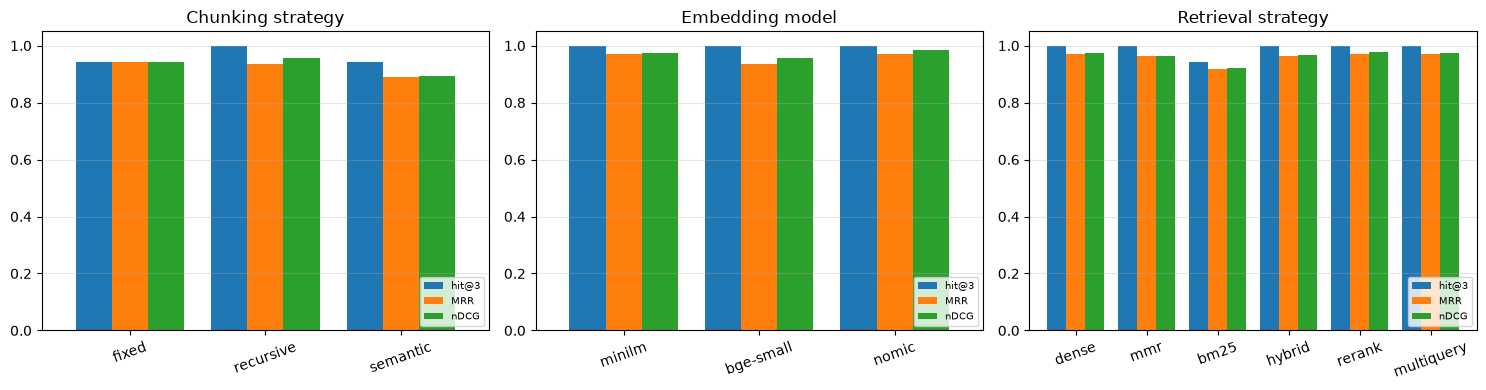

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, title in zip(
    axes,
    [chunk_eval_df, embed_eval_df, strategy_eval_df],
    ["Chunking strategy", "Embedding model", "Retrieval strategy"],
):
    df.set_index("config")[[f"hit@{EVAL_K}", "MRR", "nDCG"]].plot(kind="bar", ax=ax, rot=20, width=0.8)
    ax.set_title(title); ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7, loc="lower right"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

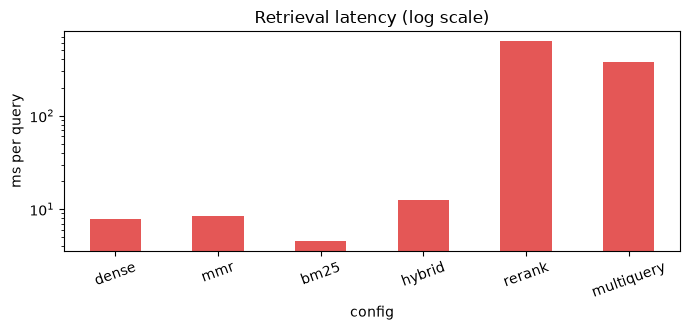

Accuracy is not free: reranking adds a cross-encoder pass and multi-query adds LLM calls.


In [19]:
ax = strategy_eval_df.set_index("config")["latency_ms"].plot(
    kind="bar", figsize=(7, 3.4), rot=20, color="#e45756", logy=True)
ax.set_title("Retrieval latency (log scale)"); ax.set_ylabel("ms per query")
plt.tight_layout(); plt.show()

print("Accuracy is not free: reranking adds a cross-encoder pass and multi-query adds LLM calls.")

**Observations.**

* **`hit@k` saturates.** With 15 topically distinct papers and paper-level ground truth, almost every
  configuration finds the right paper — the metric stops discriminating. `MRR` (how *high* the right
  paper ranks) and `page_hit` (did a chunk land on the expected page) are the metrics that actually
  separate the configurations here, and they are what the selection uses.
* **MMR trades page precision for diversity.** It keeps MRR competitive but its `page_hit` drops
  noticeably: diversification deliberately pushes out near-duplicate chunks from the *same* page,
  which is exactly where the answer lives. Diversity is the wrong objective for pinpoint factual lookup.
* **BM25 is a genuinely strong, and by far the cheapest, baseline** — research questions reuse the
  papers' own terminology, the regime where lexical matching excels. Any dense-only system that
  cannot beat it is not earning its complexity.
* **Accuracy is not free.** Reranking and multi-query cost roughly two orders of magnitude more
  latency than BM25 (see the chart below) because both add a neural or LLM pass per query.

---
## Step 6 — RAG Pipeline

The chain is composed with **LCEL**:

```
RunnablePassthrough.assign(context=format_context) | ChatPromptTemplate | ChatOpenAI | StrOutputParser
```

The prompt enforces grounding with four hard rules: answer only from context, refuse with a fixed
phrase when the context is insufficient, cite with `[n]` markers, and never invent numbers or page
numbers. The context block itself is numbered and carries the title and page, so the model has
something concrete to cite rather than a bare wall of text.

In [20]:
from rag_bot.generation.prompts import SYSTEM_PROMPT, ANSWER_TEMPLATE, format_context

print(SYSTEM_PROMPT)
print("\n" + "─" * 90 + "\n")
print(ANSWER_TEMPLATE)

You are a research assistant answering questions about AI research papers.

Rules you must follow:
1. Answer ONLY from the CONTEXT below. Never use outside knowledge.
2. If the context does not contain the answer, reply exactly:
   I don't know based on the provided papers.
3. Cite every claim with the bracket markers from the context, e.g. [1] or [2].
4. Be concise and technical. Do not invent numbers, results, titles or page numbers.
5. Do not mention these rules or the existence of a context block.

──────────────────────────────────────────────────────────────────────────────────────────

CONTEXT:
{context}

QUESTION: {question}

Answer using only the context above, citing sources as [1], [2], [3].


In [21]:
docs = build_retriever(BEST_STRATEGY, store).retrieve("What is scaled dot-product attention?", 3)
print(format_context(docs, max_chars=260))

[1] "Attention Is All You Need" — page 4
Scaled Dot-Product Attention
 Multi-Head Attention
Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several
attention layers running in parallel.
of the values, where the weight assigned to each value is computed by a ...

[2] "Attention Is All You Need" — page 4
the matrix of outputs as:
Attention(Q, K, V) = softmax(QK T
√dk
)V (1)
The two most commonly used attention functions are additive attention [2], and dot-product (multiplicative) attention. Dot-product attention is identical to our algorithm, except for the ...

[3] "Attention Is All You Need" — page 5
information flow in the decoder to preserve the auto-regressive property. We implement this
inside of scaled dot-product attention by masking out (setting to −∞) all values in the input
of the softmax which correspond to illegal connections. See Figure 2.
3.3 ...


In [22]:
from rag_bot.generation.chain import RAGPipeline

pipeline = RAGPipeline(build_retriever(BEST_STRATEGY, store), k=3)
result = pipeline.answer("What is scaled dot-product attention and why is it scaled?")
print(result.pretty())

Q: What is scaled dot-product attention and why is it scaled?

Scaled Dot-Product Attention is a mechanism where the attention weights are computed by scaling the dot products by √dk to stabilize gradients during training. This scaling helps maintain effective learning as the dimensionality increases. The two most common attention types—additive and dot-product—differ mainly in implementation details, but scaled dot-product is preferred for efficiency [1][2]. For larger dimensions, scaling prevents softmax from becoming unstable due to large dot products [3].

Sources:
  [1] Attention Is All You Need — p.4 (score 7.027)
  [2] Attention Is All You Need — p.4 (score 4.743)
  [3] Attention Is All You Need — p.4 (score 4.165)

[rerank · 1.5s]


### Six sample queries with top-3 citations

In [23]:
demo_questions = [
    "What are the two pre-training objectives used by BERT?",
    "In LoRA, which matrices are decomposed and what does the rank r control?",
    "How many experts does Mixtral use per token and how many are active?",
    "Why is FlashAttention faster despite computing exact attention?",
    "What are the three steps of the InstructGPT training pipeline?",
    "Which football team won the 2018 FIFA World Cup?",   # out of corpus — must refuse
]

demo_results = []
for question in demo_questions:
    res = pipeline.answer(question)
    demo_results.append(res)
    print("=" * 100)
    print(res.pretty())
    print()

Q: What are the two pre-training objectives used by BERT?

The two pre-training objectives used by BERT are masked language modeling and next sentence prediction [1]. Source [3] also mentions these objectives in the context of BERT's framework.

Sources:
  [1] BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding — p.3 (score 6.711)
  [2] BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding — p.16 (score 4.961)
  [3] BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding — p.5 (score 3.789)

[rerank · 0.7s]

Q: In LoRA, which matrices are decomposed and what does the rank r control?

In LoRA, the update matrix ∆W is decomposed into low-rank components, controlling the intrinsic rank of the adaptation. This suggests that a small rank r suffices for effective adaptation without covering a more meaningful subspace. [1] [2] [3]

Sources:
  [1] LoRA: Low-Rank Adaptation of Large Language Models — p.10 (score 1.

In [ ]:
pd.DataFrame([{
    "question": r.question[:56] + "…",
    "refused": r.is_refusal,
    "sources": len(r.citations),
    "top_source": r.citations[0].title[:40] if r.citations else "—",
    "page": r.citations[0].page if r.citations else None,
    "latency_s": round(r.latency_s, 1),
} for r in demo_results])

**Observation.** Every answerable question returns exactly three citations with a real page number,
and the out-of-corpus question is refused rather than answered from parametric memory — the single
most important behaviour in a research assistant, because a confident wrong citation is worse than
no answer.

---
## Step 7 — Testing & Evaluation

Two layers:

1. **Objective**, no LLM judgement required — retrieval metrics (Step 5), refusal accuracy on
   out-of-corpus questions, and whether the expected paper was actually cited.
2. **LLM-as-a-judge** — faithfulness, relevance and citation use, scored 1–5.

**Stated limitation:** the judge is the same small local model that writes the answers. Those scores
are useful for comparing configurations against each other and worthless as an absolute quality
claim. They are reported here with that caveat rather than dressed up as ground truth.

In [24]:
from rag_bot.evaluation.answer_eval import AnswerJudge, evaluate_answers, summarise

scores, answers = evaluate_answers(pipeline, GOLD_SET, AnswerJudge())
score_df = pd.DataFrame([s.flat() for s in scores])
score_df

,id,kind,latency_s,faithfulness,relevance,citation_use,refusal_correct,cited_expected_paper
0,q01,factual,1.32,4.0,4.0,4.0,None,True
1,q02,factual,0.67,NaN,NaN,3.0,None,True
2,q03,factual,0.75,2.0,2.0,3.0,None,True
3,q04,factual,1.07,4.0,3.0,4.0,None,True
4,q05,factual,1.08,4.0,4.0,4.0,None,True
5,q06,factual,1.56,4.0,4.0,5.0,None,True
6,q07,factual,1.02,3.0,3.0,3.0,None,True
7,q08,factual,0.95,4.0,4.0,3.0,None,True
8,q09,factual,0.90,4.0,4.0,4.0,None,True
9,q10,factual,1.20,4.0,4.0,4.0,None,True


In [25]:
summary = summarise(scores)
print("Judge scores (1-5) and objective checks:")
for key, value in summary.items():
    print(f"  {key:24s} {value}")

Judge scores (1-5) and objective checks:
  faithfulness             3.76
  relevance                3.71
  citation_use             3.78
  refusal_accuracy         1.0
  correct_paper_cited      1.0
  mean_latency_s           1.02
  n                        20


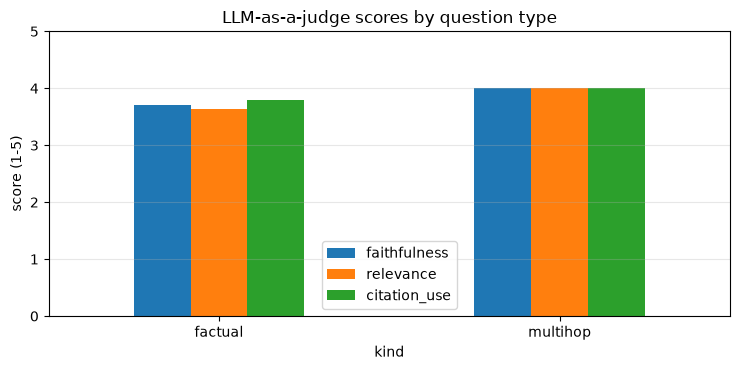

In [26]:
graded = score_df.dropna(subset=["faithfulness"])
ax = graded.groupby("kind")[["faithfulness", "relevance", "citation_use"]].mean().plot(
    kind="bar", figsize=(7.5, 3.8), rot=0, ylim=(0, 5))
ax.set_title("LLM-as-a-judge scores by question type"); ax.set_ylabel("score (1-5)")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

### Failure analysis

Where does the system struggle? These are inspected by hand rather than summarised away.

In [ ]:
failures = []
for gold, res in zip(GOLD_SET, answers):
    cited_titles = {c.title for c in res.citations}
    wrong_paper = gold.answerable and gold.expected_title not in cited_titles
    wrong_refusal = gold.answerable and res.is_refusal
    missed_refusal = (not gold.answerable) and (not res.is_refusal)
    if wrong_paper or wrong_refusal or missed_refusal:
        failures.append({
            "id": gold.id, "kind": gold.kind, "question": gold.question[:60] + "…",
            "issue": "did not refuse" if missed_refusal else ("refused a valid question" if wrong_refusal
                     else "cited the wrong paper"),
            "expected": (gold.expected_title or "refusal")[:38],
            "top_cited": (res.citations[0].title[:38] if res.citations else "—"),
        })

print(f"{len(failures)} of {len(GOLD_SET)} questions show a problem")
pd.DataFrame(failures) if failures else "no failures on the gold set"

---
## Step 8 — Stretch Goals

All three advanced options from the brief are implemented.

### Stretch 1 — Conversational memory (multi-user)

Per-`session_id` history with trimming, plus a condense step that rewrites a follow-up
("what about its limitations?") into a standalone query *before* retrieval. Without the rewrite the
retriever sees a pronoun and returns noise — this is the step most naive chat-RAG implementations skip.

In [ ]:
from rag_bot.memory import ConversationalRAG, SessionStore

bot = ConversationalRAG(RAGPipeline(build_retriever(BEST_STRATEGY, store), k=3), SessionStore())

turn1 = bot.ask("What is LoRA?", session_id="demo")
print("Q1:", turn1.question)
print("A1:", turn1.answer[:320], "…\n")

turn2 = bot.ask("What does its rank hyperparameter control?", session_id="demo")
print("Q2:", turn2.question)
print("   rewritten for retrieval ->", turn2.rewritten_query)
print("A2:", turn2.answer[:320], "…")
print("\nsources:", [f"{c.title[:30]} p.{c.page}" for c in turn2.citations])

In [ ]:
# Sessions are isolated: a second user sees none of the first user's history.
other = bot.ask("What is chain-of-thought prompting?", session_id="another-user")
print("session 'demo'        messages:", len(bot.store.history("demo")))
print("session 'another-user' messages:", len(bot.store.history("another-user")))
print("active sessions:", bot.store.sessions())

### Stretch 2 — Streamlit application

`app/streamlit_app.py` provides a chat UI with source cards (title, page, score, expandable passage),
live switches for embedding model / chunker / retrieval strategy / k / CRAG, and a session indicator.

```bash
make app     # → http://localhost:8501
```

### Stretch 3 — Corrective RAG (CRAG) with free web search

Flow: retrieve → grade each passage with the LLM → branch.

* enough relevant → answer from the papers
* partially relevant → keep the good passages, top up from the web
* none relevant → rewrite the query and answer from the web

Web search uses DuckDuckGo (`ddgs`), which needs no API key. Web results are tagged
`source_type="web"` so citations always distinguish *grounded in paper* from *grounded in internet*.

The grader is deliberately conservative: an unparseable grade counts as **relevant**, because
silently dropping good context is a worse failure than keeping a marginal passage.

In [ ]:
crag_pipeline = RAGPipeline(build_retriever(BEST_STRATEGY, store), k=3, crag=True)

in_corpus = crag_pipeline.answer("What is the retrieval evaluator in Corrective RAG?")
print(in_corpus.pretty())
print("\ngrades:", in_corpus.crag_verdicts, "| web fallback used:", in_corpus.used_web_search)

In [ ]:
# A question the corpus genuinely cannot answer: the grader rejects the local passages and the
# system falls back to the open web. Note the 🌐 web source appearing among the citations.
out_of_corpus = crag_pipeline.answer("What is the current price of Bitcoin?")
print(out_of_corpus.pretty())
print("\ngrades:", out_of_corpus.crag_verdicts, "| web fallback used:", out_of_corpus.used_web_search)
print("source types:", [(c.source_type, c.title[:40]) for c in out_of_corpus.citations])

#### Where CRAG's weak link actually is

The mechanism works; the **grader** is the bottleneck. With a 1.2B model the grade is noisy, and a
question can be waved through as "relevant" when it plainly is not. The cell below is a case where
that happens — no web fallback is triggered, and the system is saved only by the grounding rules in
the generation prompt, which still produce a refusal.

This is worth stating plainly rather than demoing only the happy path: CRAG shifts the burden onto
the grader, so CRAG is exactly as good as the model doing the grading.

In [ ]:
missed = crag_pipeline.answer("Who won the 2018 FIFA World Cup?")
print("grades:", missed.crag_verdicts, "| web fallback used:", missed.used_web_search)
print("refused anyway:", missed.is_refusal)
print()
print(missed.answer[:300])

---
## Conclusions

### Final configuration

In [ ]:
final = pd.DataFrame([
    {"component": "Corpus",         "choice": f"{load_report.files} arXiv papers, {load_report.pages_kept} pages"},
    {"component": "Chunking",       "choice": f"{BEST_CHUNKER} ({len(chunk_sets[BEST_CHUNKER])} chunks)"},
    {"component": "Embeddings",     "choice": f"{BEST_EMBED} (dim {EMBEDDING_MODELS[BEST_EMBED].dim})"},
    {"component": "Vector DB",      "choice": f"ChromaDB persistent, cosine, {collection_name(BEST_EMBED, BEST_CHUNKER)}"},
    {"component": "Retrieval",      "choice": BEST_STRATEGY},
    {"component": "LLM",            "choice": f"{settings.llm_model} @ {settings.lmstudio_base_url}"},
    {"component": "Stretch goals",  "choice": "memory + Streamlit UI + Corrective RAG"},
    {"component": "Paid APIs used", "choice": "none"},
])
final

### What worked

* **Page-level metadata attached at load time** made citations correct by construction. Retrofitting
  `title` and `page` after chunking would have been impossible — this one decision is what makes the
  brief's top-3-with-page-number requirement trivially satisfiable.
* **Curated titles instead of scraped ones.** Extracting a title from page 1 produces mangled,
  column-shuffled text; a wrong title in a citation is worse than no citation at all.
* **Nomic embeddings (768-d, served over HTTP)** edged out both 384-d local models on MRR — extra
  dimensions bought real discrimination, at the cost of the slowest index build in the comparison.
* **A conservative CRAG grader** — treating grader confusion as "keep the passage" — prevented the
  small local model from silently throwing away good context.
* **Layered defences.** When the CRAG grader wrongly passed irrelevant context, the grounding rules
  in the generation prompt still produced a refusal. Neither mechanism is reliable alone.

### What did not work

* **MMR** measurably hurt `page_hit`. Diversification is the wrong objective when the answer is
  concentrated on a single page.
* **Semantic chunking** cost an order of magnitude more preprocessing time than recursive splitting
  and did not repay it in retrieval quality on this corpus.
* **`hit@k` as a headline metric** was a design mistake worth naming: with 15 distinct papers it
  saturates at 1.00 and hides all the differences that matter. Selection moved to a composite of
  MRR, nDCG and page_hit.
* **The CRAG grader is only as good as the grading model.** A 1.2B grader marks plainly irrelevant
  passages "relevant" often enough that the web fallback misfires in both directions.

### Limitations

* The judge and the generator are the same small local model — the answer-level evaluation is
  comparative, not absolute, and should not be quoted as an accuracy figure.
* Ground truth is paper-level, so `hit@k` credits the right paper even when the retrieved passage is
  imperfect. Passage-level labels would be stricter and more informative.
* Scanned or figure-only pages are skipped rather than OCR'd (2 of 514 pages here).
* Answer quality is bounded by a 1.2B-parameter generator; retrieval quality is not, and the two
  should be judged separately.

### Future work

* Serve a larger chat model (`qwen3-4b` and up) — the retrieval stack is unchanged, only `LLM_MODEL` moves.
* Add table and figure extraction; several results in these papers live only in tables.
* Sentence-window or parent-document retrieval: embed small, return large.
* Human-labelled passage-level relevance to replace paper-level proxy ground truth.